Gold_prices_predoctions (1).ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1tQZNhKrzyCYsncQhIK42Cd1taKbl4woO

<h1 style="text-align:center ">Gold Price Predictions</h1>

 ## Project Data [   source](https://www.kaggle.com/datasets/altruistdelhite04/gold-price-data)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics




## Loading the data

In [2]:

gold_data=pd.read_csv('/content/gld_price_data.csv')



## exploring the dataset



In [3]:

gold_data.shape

gold_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


## have Missing values or nulls?

In [4]:

gold_data.isnull().sum()



,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


## projecting  parts of the data **first & last 5 rows respectively**

In [5]:

gold_data.head()

gold_data.tail()



,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


## statistical measurement of the data  

In [6]:

gold_data.describe()



,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


## converting the date into a separate year month day columns , and dropin the old date      

In [7]:

# 1. Timestampتحويل عمود التاريخ إلى
gold_data['Date'] = pd.to_datetime(gold_data['Date'], format='%m/%d/%Y')

# 2.Index للـ DataFrame تعيين عمود التاريخ كـ
gold_data.set_index('Date', inplace=True)


gold_data.head()


,SPX,GLD,USO,SLV,EUR/USD
Date,,,,,
2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


## contracting the corelation between feather

In [8]:

corelation = gold_data.corr()



## visualizing the corelation via a heatmap

<Axes: >

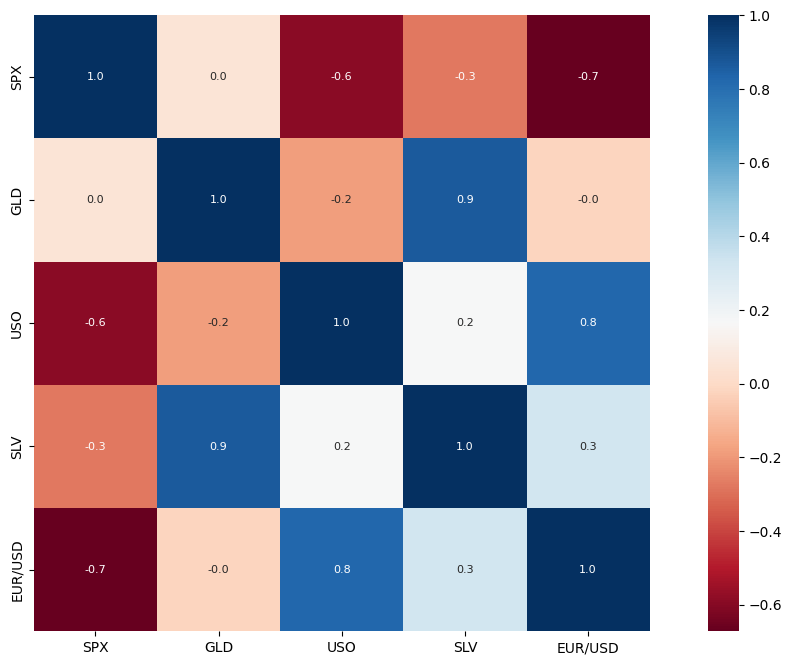

In [9]:

# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (15,8))
sns.heatmap(corelation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap="RdBu")



### corelation of the gold values

In [10]:

# Correlation between all numerical features
correlation_matrix = gold_data.corr()

print(correlation_matrix)

corelation['GLD']



              SPX       GLD       USO       SLV   EUR/USD
SPX      1.000000  0.049345 -0.591573 -0.274055 -0.672017
GLD      0.049345  1.000000 -0.186360  0.866632 -0.024375
USO     -0.591573 -0.186360  1.000000  0.167547  0.829317
SLV     -0.274055  0.866632  0.167547  1.000000  0.321631
EUR/USD -0.672017 -0.024375  0.829317  0.321631  1.000000


,GLD
SPX,0.049345
GLD,1.000000
USO,-0.186360
SLV,0.866632
EUR/USD,-0.024375


### checking the distribution of the gld            

<Axes: xlabel='GLD', ylabel='Count'>

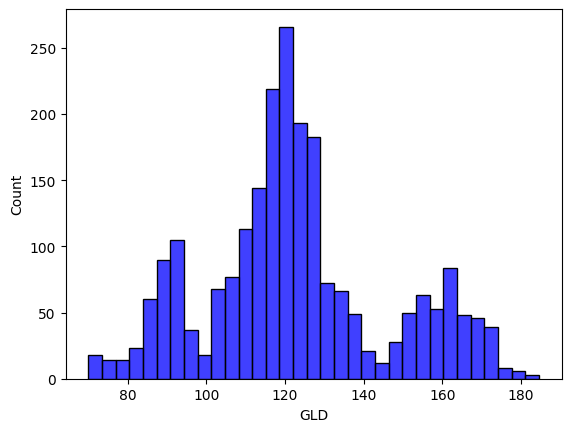

In [11]:

sns.histplot(gold_data['GLD'],color="blue")



### Checking for duplicates

In [12]:

gold_data.duplicated().sum()



np.int64(0)

### Outlier detection using Boxplots

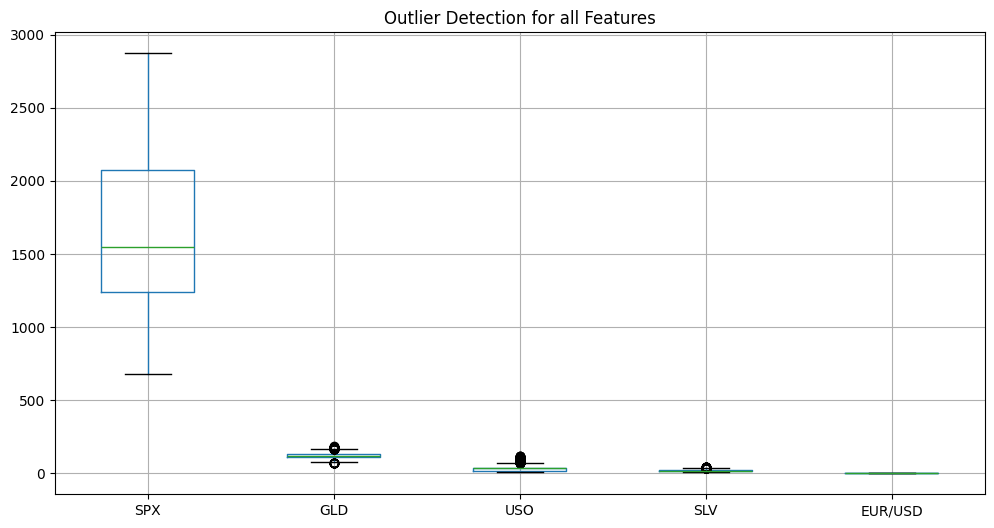

In [13]:

plt.figure(figsize=(12, 6))
gold_data.boxplot()
plt.title('Outlier Detection for all Features')
plt.show()



### Visualizing the strong relationship between Silver and Gold

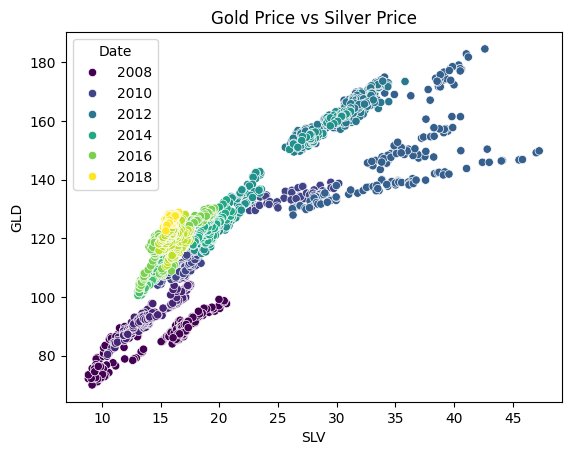

In [14]:

sns.scatterplot(x='SLV', y='GLD', data=gold_data, hue=gold_data.index.year, palette='viridis')
plt.title('Gold Price vs Silver Price')
plt.show()



### Gold price trend over the years

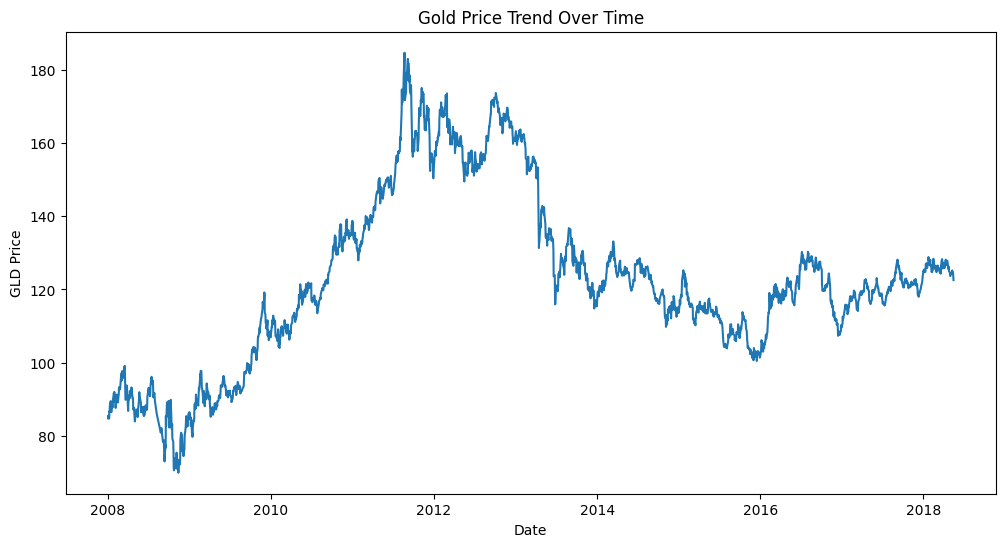

In [15]:

plt.figure(figsize=(12, 6))
sns.lineplot(x=gold_data.index, y='GLD', data=gold_data)
plt.title('Gold Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('GLD Price')
plt.show()


### selver price trend over the years

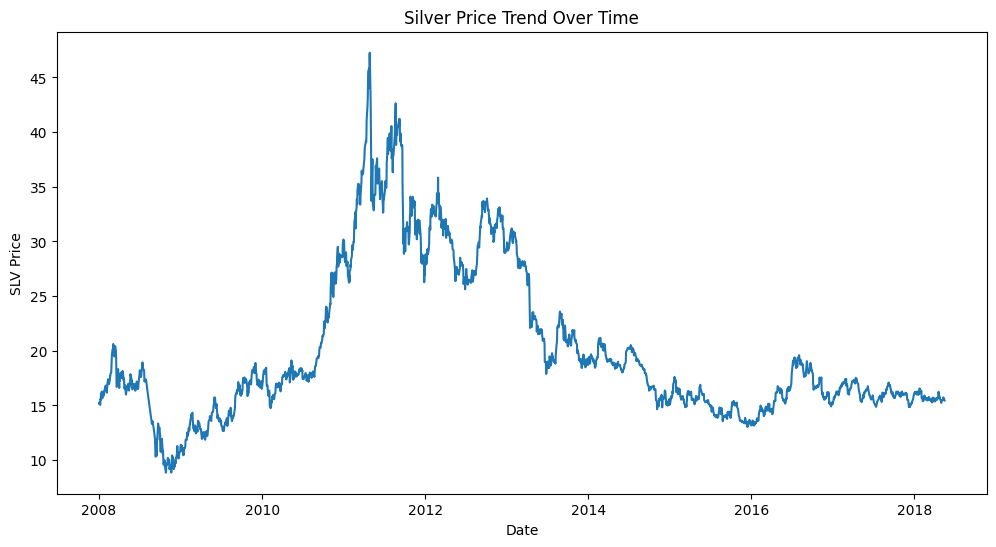

In [16]:

plt.figure(figsize=(12, 6))
sns.lineplot(x=gold_data.index, y='SLV', data=gold_data)
plt.title('Silver Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('SLV Price')
plt.show()



## preparing the data for the model and  removing
### We will use   todays data to predict tomorrow's gold price  & drop the un important data month dayofweek


In [17]:

# Create a new column that pulls tomorrow's Gold price into today's row
gold_data['Target_Next_Day_GLD'] = gold_data['GLD'].shift(-1)

# dorp last row
gold_data = gold_data.dropna()

# prepare the target and the training data
y = gold_data['Target_Next_Day_GLD']
X = gold_data.drop(columns=['Target_Next_Day_GLD'])



## Spliting the data to test and train

time_based split/chornological split


In [18]:

split_index = int(len(X) * 0.8)

x_train = X.iloc[:split_index]
x_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=2),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [19]:
best_rf = grid_search.best_estimator_

## Train the models

## Model training and  prediction

In [20]:

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=2),
    "Gradient Boosting": GradientBoostingRegressor(random_state=2)
}
# 2. Initialize the results dictionary
results = {
    "Model": [],
    "R2 Score": [],
    "RMSE": [],
    "MAE": []
}
print(f"\n{'Model Name':<20} | {'R² Score':<10} | {'RMSE':<10} | {'MAE':<10}")
print("-" * 60)

# 3. Train and evaluate loop
for name, model in models.items():
    # Train and predict
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)

    # Calculate metrics
    r2 = metrics.r2_score(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse=np.sqrt(mse)
    mae = metrics.mean_absolute_error(y_test, predictions)

    # Store results
    results["Model"].append(name)
    results["R2 Score"].append(r2)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)

    # Print formatted output to console
    print(f"{name:<20} | {r2:<10.4f} | {rmse:<10.2f} | {mae:<10.2f}")

# pred=rand1ome_forest.predict(x_test)
# x = np.ravel(y_test)
# y = np.ravel(pred)
# plt.figure(figsize=(8, 8))
# sns.regplot(x=x, y=y,
#             scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
#             line_kws={'color': 'red', 'linewidth': 2})

# plt.title("True Forecasting: Actual vs Predicted")
# # plt.show()




Model Name           | R² Score   | RMSE       | MAE       
------------------------------------------------------------
Linear Regression    | 0.9584     | 0.99       | 0.73      
Random Forest        | 0.9189     | 1.38       | 1.08      
Gradient Boosting    | 0.9022     | 1.51       | 1.25      


## see the model performance  

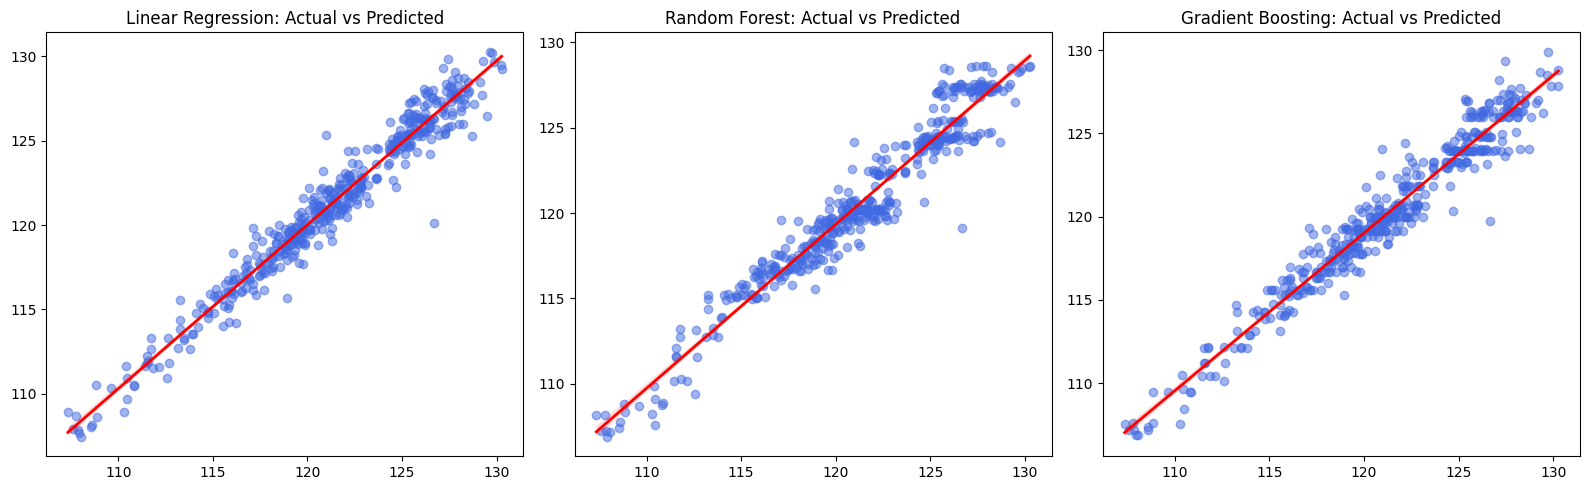

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.ravel(y_test)

for ax, (model_name, model) in zip(axes, list(models.items())[:3]):
    y_pred = np.ravel(model.predict(x_test))
    ax.set_title(f"{model_name}: Actual vs Predicted")
    sns.regplot(x=x, y=y_pred, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
                line_kws={'color': 'red', 'linewidth': 2})

plt.tight_layout()
plt.show()



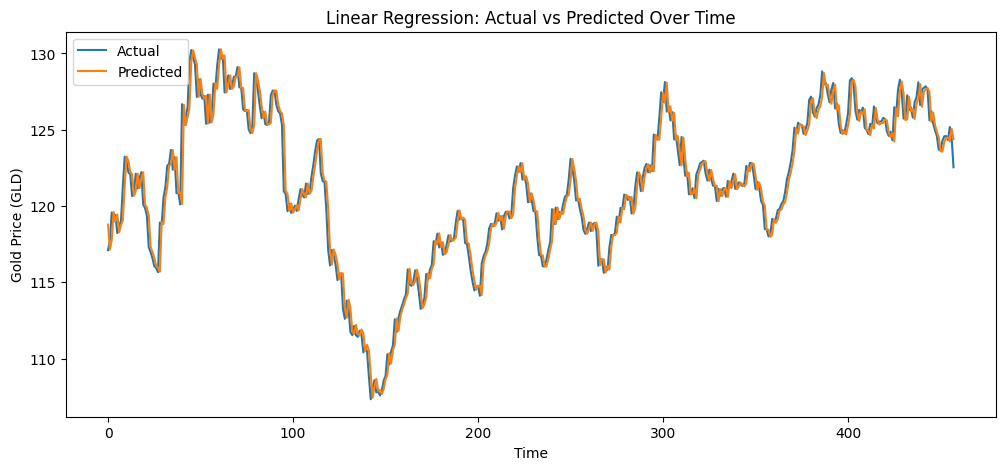

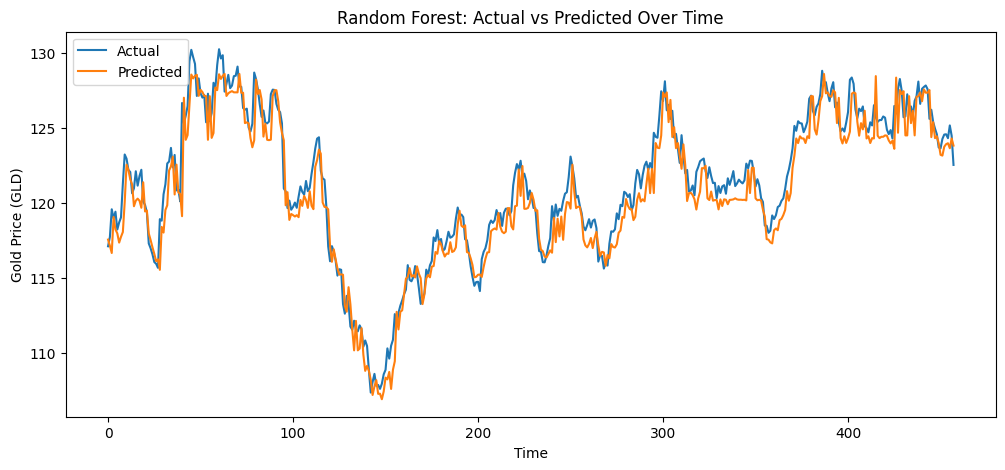

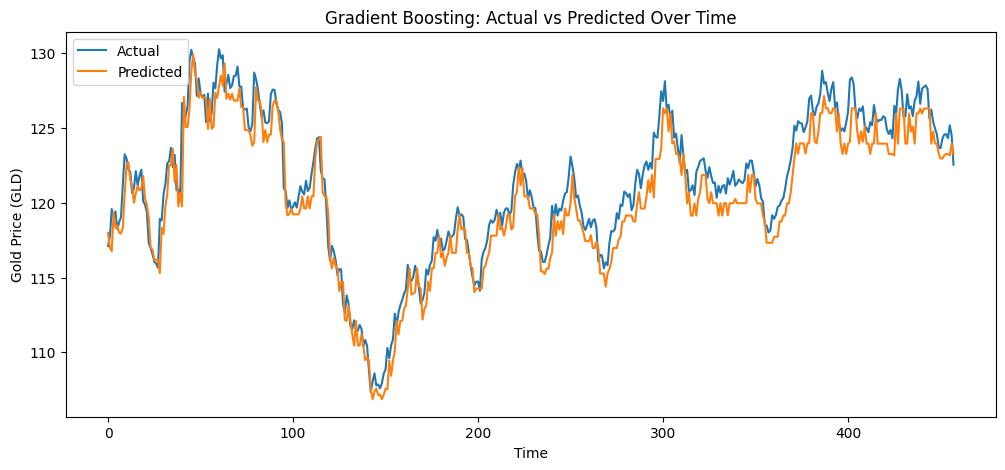

In [22]:
for model_name, model in models.items():

    y_pred = model.predict(x_test)

    plt.figure(figsize=(12, 5))

    plt.plot(y_test.values, label='Actual')
    plt.plot(y_pred, label='Predicted')

    plt.title(f'{model_name}: Actual vs Predicted Over Time')
    plt.xlabel('Time')
    plt.ylabel('Gold Price (GLD)')
    plt.legend()

    plt.show()

### converting the result into a dataname for visualization        

In [23]:

results_df=pd.DataFrame(results)
results_df



,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.958374,0.987640,0.730315
1,Random Forest,0.918890,1.378646,1.084788
2,Gradient Boosting,0.902170,1.514094,1.250014


### 4. Visualize the comparison

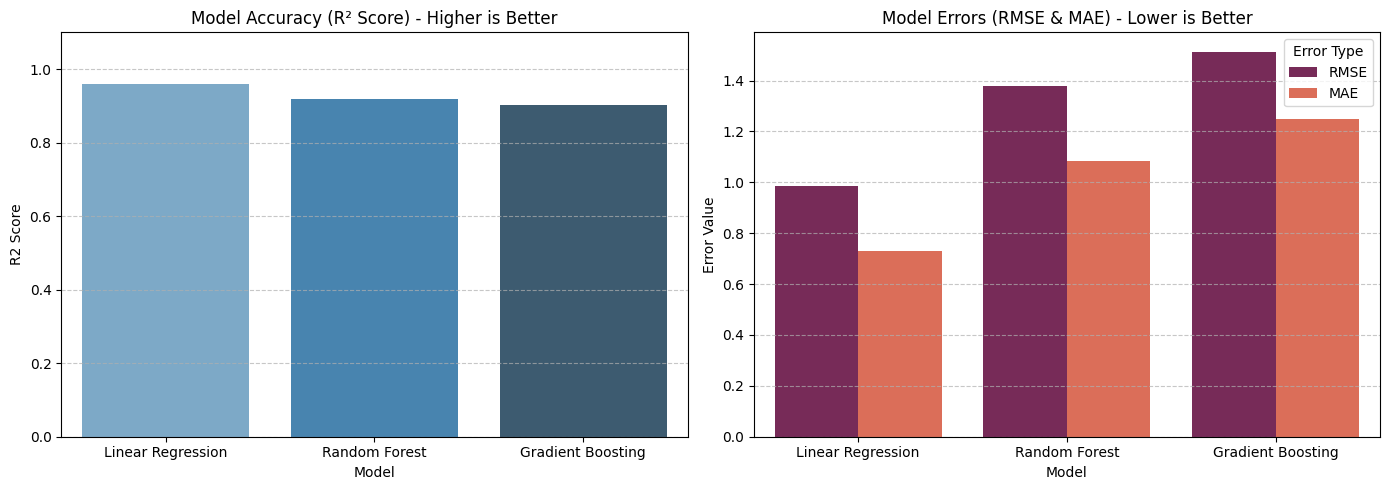

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# --- Subplot 1: R2 Score Accuracy
sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    legend=False,
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Model Accuracy (R² Score) - Higher is Better")
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Errors MSE and MAE
# We use pd.melt to restructure the dataframe so Seaborn can group the error bars side-by-side
error_df = results_df.melt(id_vars="Model", value_vars=["RMSE", "MAE"],
                           var_name="Error Type", value_name="Error Value")

sns.barplot(data=error_df, x="Model", y="Error Value", hue="Error Type", ax=axes[1], palette="rocket")
axes[1].set_title("Model Errors (RMSE & MAE) - Lower is Better")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show();



**Linear Regression it is a Beast Model**

In [25]:
print("Linear Regression")
print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Linear Regression
R2 Score: 0.9021699276695035
RMSE: 1.5140936727833683
MAE: 1.2500141164311183


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
lr_scaled = LinearRegression()
lr_scaled.fit(x_train_scaled, y_train)
predictions_scaled = lr_scaled.predict(x_test_scaled)

r2 = metrics.r2_score(y_test, predictions_scaled)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions_scaled))
mae = metrics.mean_absolute_error(y_test, predictions_scaled)

print("Linear Regression after Scaling")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Linear Regression after Scaling
R2: 0.9583740673667587
RMSE: 0.9876397157390617
MAE: 0.7303154200091664


In [28]:
from xgboost import XGBRegressor
from sklearn import metrics
import numpy as np

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=2
)

# Train
xgb_model.fit(x_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(x_test)

# Metrics
xgb_r2 = metrics.r2_score(y_test, xgb_predictions)
xgb_mse = metrics.mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = metrics.mean_absolute_error(y_test, xgb_predictions)

print("XGBoost")
print("R2 Score:", xgb_r2)
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)

XGBoost
R2 Score: 0.9459493321932256
RMSE: 1.125426376212996
MAE: 0.8663635756025689
